# Snabb EDA: Bedrägliga korttransaktioner

**Förslag:** Klassificera korttransaktioner som normala eller möjliga bedrägerier, med fokus på att hantera att bedrägerier är mycket ovanliga.

**Källa:** Kaggle, Credit Card Fraud Detection (Machine Learning Group, ULB) https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
**Licens:** Kontrollera på Kaggle-sidan och skriv in här.

In [1]:
import shutil
from pathlib import Path
 
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
 
RAW_DIR = Path("../data/raw/fraud")
RAW_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = RAW_DIR / "creditcard.csv"
 
if not CSV_PATH.exists():
    cache = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud"))
    shutil.copy2(next(cache.glob("*.csv")), CSV_PATH)
 
df = pd.read_csv(CSV_PATH)
print(df.shape)
df.info()
df.head()

c:\Projekt Data Science\flotation-silica-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 66.0M/66.0M [00:03<00:00, 21.0MB/s]

Extracting files...


(284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Datakvalitet

In [2]:
print("Saknade värden:", df.isna().sum().sum())
print("Dubblerade rader:", df.duplicated().sum())
print("Dubblerade rader bland bedrägerier:", df[df["Class"] == 1].duplicated().sum())

Saknade värden: 0
Dubblerade rader: 1081
Dubblerade rader bland bedrägerier: 19


## Målvariabel: hur ovanliga är bedrägerierna?

In [3]:
counts = df["Class"].value_counts()
print(counts)
print(f"Andel bedrägerier: {df['Class'].mean():.3%}")
print(f"En modell som alltid säger 'normal' får {1 - df['Class'].mean():.2%} accuracy")

Class
0    284315
1       492
Name: count, dtype: int64
Andel bedrägerier: 0.173%
En modell som alltid säger 'normal' får 99.83% accuracy


## Tid

`Time` är sekunder sedan första transaktionen i datasetet.

Tidsperiod: 1.9999074074074075 dygn
      transaktioner  bedragerier   andel
hour                                    
0              3963            2  0.0005
1              2217            2  0.0009
2              1576           21  0.0133
3              1821           13  0.0071
4              1082            6  0.0055
5              1681           11  0.0065
6              1831            3  0.0016
7              3368           23  0.0068
8              5179            5  0.0010
9              7878           15  0.0019
10             8288            2  0.0002
11             8517           43  0.0050
12             7732            9  0.0012
13             7585            9  0.0012
14             8029           13  0.0016
15             7836           14  0.0018
16             7786           14  0.0018
17             7882           12  0.0015
18             8607           15  0.0017
19             7994            7  0.0009
20             8980            8  0.0009
21             9895  

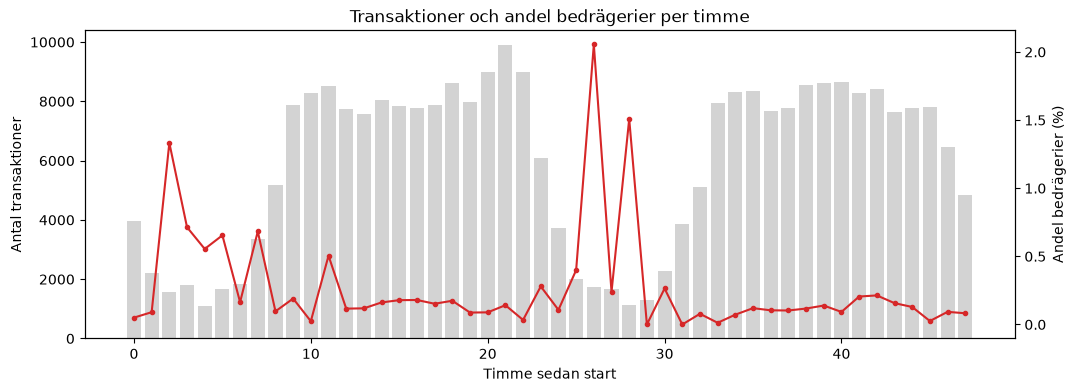

In [4]:
df["hour"] = (df["Time"] // 3600).astype(int)
print("Tidsperiod:", df["Time"].max() / 3600 / 24, "dygn")
 
per_hour = df.groupby("hour")["Class"].agg(["size", "sum", "mean"])
per_hour.columns = ["transaktioner", "bedragerier", "andel"]
print(per_hour.round(4))
 
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(per_hour.index, per_hour["transaktioner"], color="lightgray", label="Transaktioner")
ax1.set_xlabel("Timme sedan start")
ax1.set_ylabel("Antal transaktioner")
ax2 = ax1.twinx()
ax2.plot(per_hour.index, per_hour["andel"] * 100, color="tab:red", marker=".", label="Andel bedrägerier")
ax2.set_ylabel("Andel bedrägerier (%)")
plt.title("Transaktioner och andel bedrägerier per timme")
plt.show()

## Belopp

          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


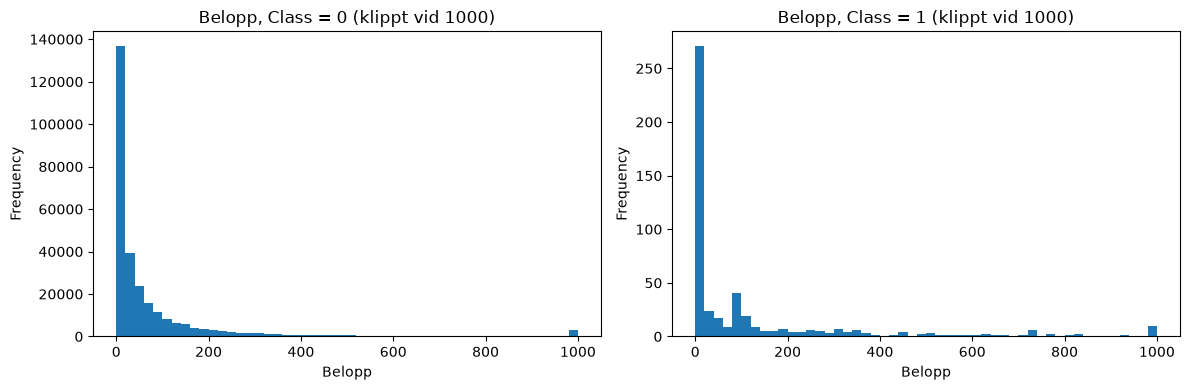

Andel transaktioner med belopp 0: 0.64%
Andel bedrägerier med belopp 0: 5.49%


In [5]:
print(df.groupby("Class")["Amount"].describe().round(2))
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, group) in zip(axes, df.groupby("Class")):
    group["Amount"].clip(upper=1000).plot(kind="hist", bins=50, ax=ax)
    ax.set_title(f"Belopp, Class = {label} (klippt vid 1000)")
    ax.set_xlabel("Belopp")
plt.tight_layout()
plt.show()
 
print("Andel transaktioner med belopp 0:", f"{(df['Amount'] == 0).mean():.2%}")
print("Andel bedrägerier med belopp 0:", f"{(df.loc[df['Class'] == 1, 'Amount'] == 0).mean():.2%}")

## De anonymiserade variablerna V1–V28

Variablerna är resultatet av en PCA-transformation. De ursprungliga variablerna är hemliga, så de går inte att tolka.

In [6]:
v_cols = [f"V{i}" for i in range(1, 29)]
diff = (df.groupby("Class")[v_cols].mean().T
        .rename(columns={0: "normal", 1: "bedrägeri"}))
diff["skillnad"] = diff["bedrägeri"] - diff["normal"]
print(diff.sort_values("skillnad", key=abs, ascending=False).round(2).head(10))
 

Class  normal  bedrägeri  skillnad
V3       0.01      -7.03     -7.05
V14      0.01      -6.97     -6.98
V17      0.01      -6.67     -6.68
V12      0.01      -6.26     -6.27
V10      0.01      -5.68     -5.69
V7       0.01      -5.57     -5.58
V1       0.01      -4.77     -4.78
V4      -0.01       4.54      4.55
V16      0.01      -4.14     -4.15
V11     -0.01       3.80      3.81


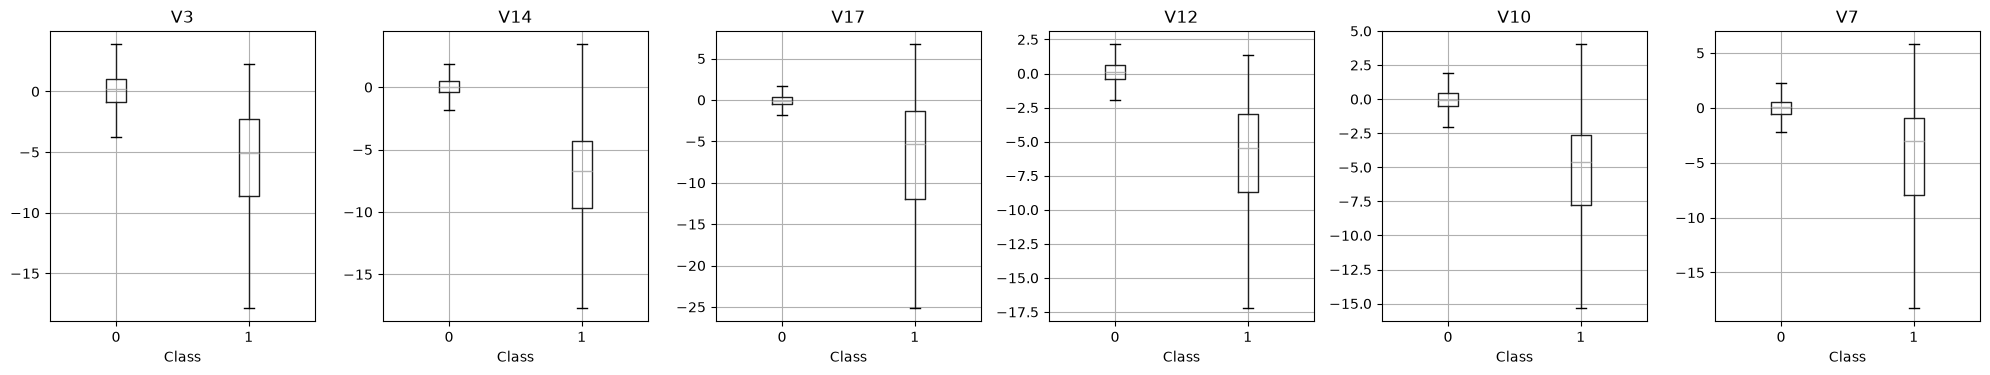

In [7]:
top = diff["skillnad"].abs().sort_values(ascending=False).index[:6]
fig, axes = plt.subplots(1, 6, figsize=(20, 4))
for ax, col in zip(axes, top):
    df.boxplot(column=col, by="Class", ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("Class")
plt.suptitle("")
plt.tight_layout()
plt.show()

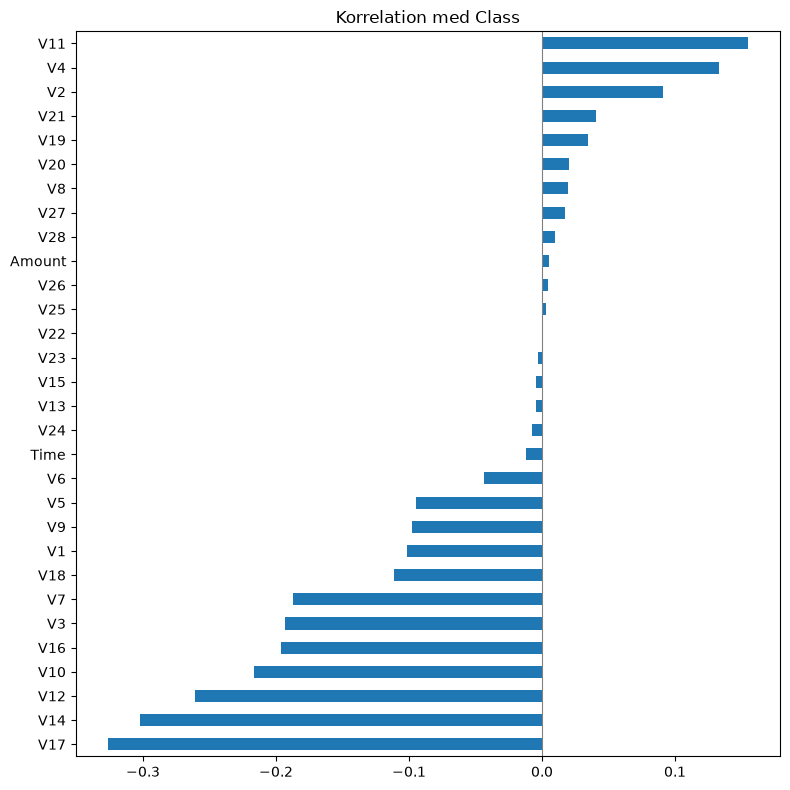

In [8]:
corr = df.corr(numeric_only=True)["Class"].drop(["Class", "hour"]).sort_values()
corr.plot(kind="barh", figsize=(8, 8), title="Korrelation med Class")
plt.axvline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

## Hur stort blir testset och valideringsset?

Med så få bedrägerier blir antalet i testdatan litet.

In [9]:
n_fraud = df["Class"].sum()
for share in [0.2, 0.3]:
    print(f"Testdata {share:.0%}: ca {int(n_fraud * share)} bedrägerier")

Testdata 20%: ca 98 bedrägerier
Testdata 30%: ca 147 bedrägerier
